'data.frame':	1319 obs. of  9 variables:
 $ Age                     : int  64 21 55 64 55 58 32 63 44 67 ...
 $ Gender                  : int  1 1 1 1 1 0 0 1 0 1 ...
 $ Heart.rate              : int  66 94 64 70 64 61 40 60 60 61 ...
 $ Systolic.blood.pressure : int  160 98 160 120 112 112 179 214 154 160 ...
 $ Diastolic.blood.pressure: int  83 46 77 55 65 58 68 82 81 95 ...
 $ Blood.sugar             : num  160 296 270 270 300 87 102 87 135 100 ...
 $ CK.MB                   : num  1.8 6.75 1.99 13.87 1.08 ...
 $ Troponin                : num  0.012 1.06 0.003 0.122 0.003 0.004 0.003 2.37 0.004 0.011 ...
 $ Result                  : chr  "negative" "positive" "negative" "positive" ...


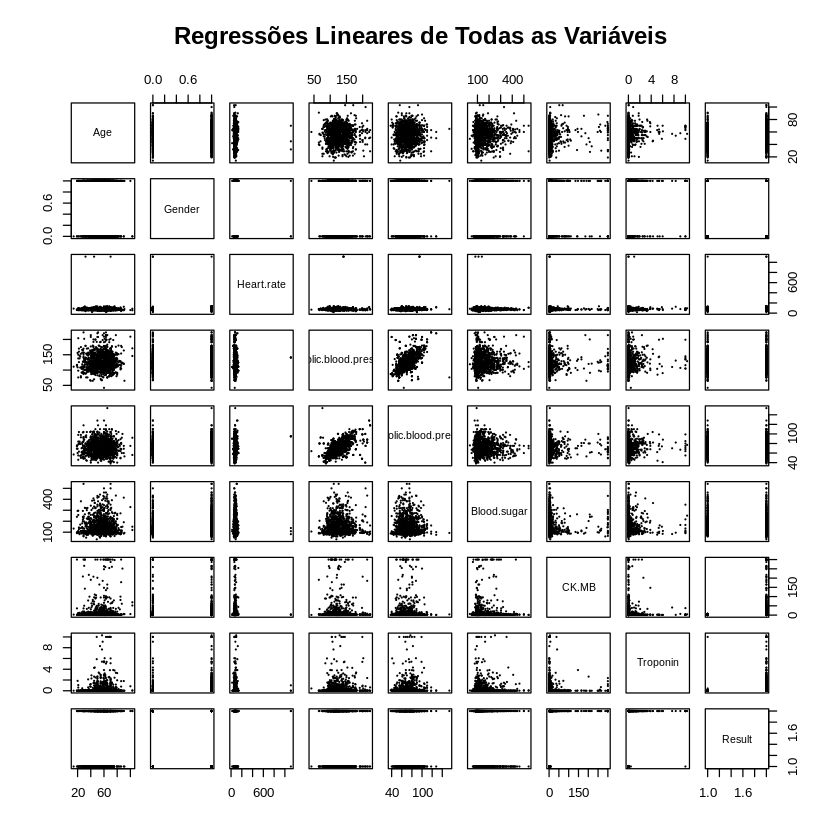

In [ ]:
f = read.csv("/content/Medicaldataset.csv")
str(f)

plot(f,pch=20, cex = 0.05, main = "Regressões Lineares de Todas as Variáveis")

'data.frame':	240 obs. of  10 variables:
 $ Age                     : int  21 55 64 55 47 37 60 52 30 50 ...
 $ Gender                  : int  1 1 1 1 1 0 1 1 1 1 ...
 $ Heart.rate              : int  94 64 70 64 76 72 92 76 63 63 ...
 $ Systolic.blood.pressure : int  98 160 120 112 120 107 151 109 110 104 ...
 $ Diastolic.blood.pressure: int  46 77 55 65 70 86 78 85 68 63 ...
 $ Blood.sugar             : num  296 270 270 300 319 274 301 227 107 269 ...
 $ CK.MB                   : num  6.75 1.99 13.87 1.08 2.57 ...
 $ Troponin                : num  1.06 0.003 0.122 0.003 0.003 0.003 0.005 0.491 0.003 0.612 ...
 $ Result                  : chr  "positive" "negative" "positive" "negative" ...
 $ Result_num              : num  1 0 1 0 0 0 0 1 1 1 ...


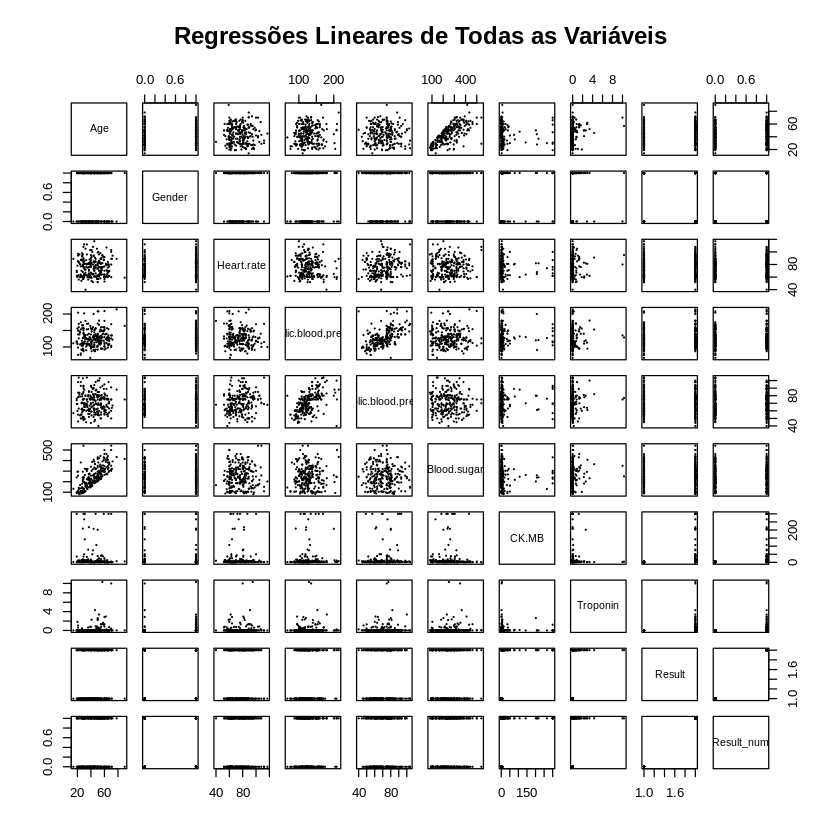

In [ ]:
f$Result_num <- ifelse(f$Result == "positive", 1, 0)
f = f[!(f$Age > 0.2 * f$Blood.sugar + 10), ]

str(f)

plot(f,pch=20, cex = 0.05, main = "Regressões Lineares de Todas as Variáveis")

In [ ]:
count1 = sum(f$Result_num == 1); cat("Total heart attacks:", count1, "\n")
count2 = sum(f$Result_num == 0); cat("Total non heart attacks:", count2, "\n")


Total heart attacks: 115 
Total non heart attacks: 125 


,2.5 %,97.5 %
(Intercept),73.59120,77.296106
Troponin,-0.75459,2.552942



Call:
lm(formula = Heart.rate ~ Troponin, data = f)

Residuals:
    Min      1Q  Median      3Q     Max 
-35.447 -12.448  -0.166   9.520  41.554 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  75.4437     0.9403  80.230   <2e-16 ***
Troponin      0.8992     0.8395   1.071    0.285    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14.07 on 238 degrees of freedom
Multiple R-squared:  0.004797,	Adjusted R-squared:  0.0006158 
F-statistic: 1.147 on 1 and 238 DF,  p-value: 0.2852


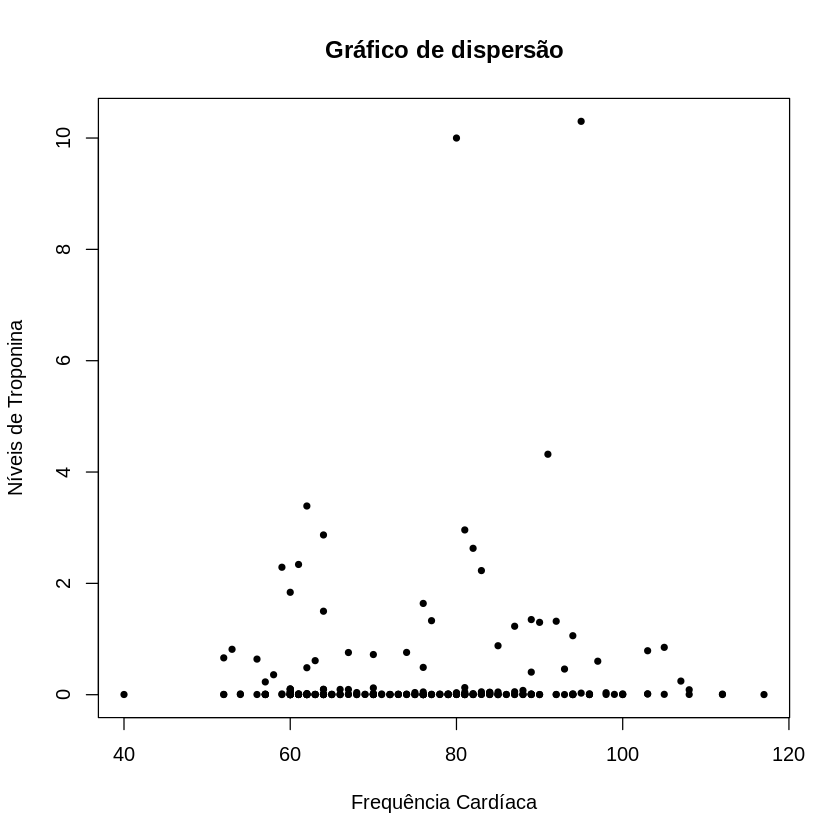

In [ ]:
modeloS=lm(Heart.rate~Troponin, data=f);
confint(modeloS)
summary(modeloS)

plot(f$Heart.rate,f$Troponin, pch=20, xlab = "Frequência Cardíaca", ylab =
  "Níveis de Troponina", main = "Gráfico de dispersão")

,2.5 %,97.5 %
(Intercept),-4.964593,53.116362
Age,4.478791,5.731249



Call:
lm(formula = Blood.sugar ~ Age, data = f)

Residuals:
   Min     1Q Median     3Q    Max 
-80.80 -53.20 -19.54  33.02 368.88 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  24.0759    14.7415   1.633    0.104    
Age           5.1050     0.3179  16.059   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 69.87 on 238 degrees of freedom
Multiple R-squared:  0.5201,	Adjusted R-squared:  0.518 
F-statistic: 257.9 on 1 and 238 DF,  p-value: < 2.2e-16


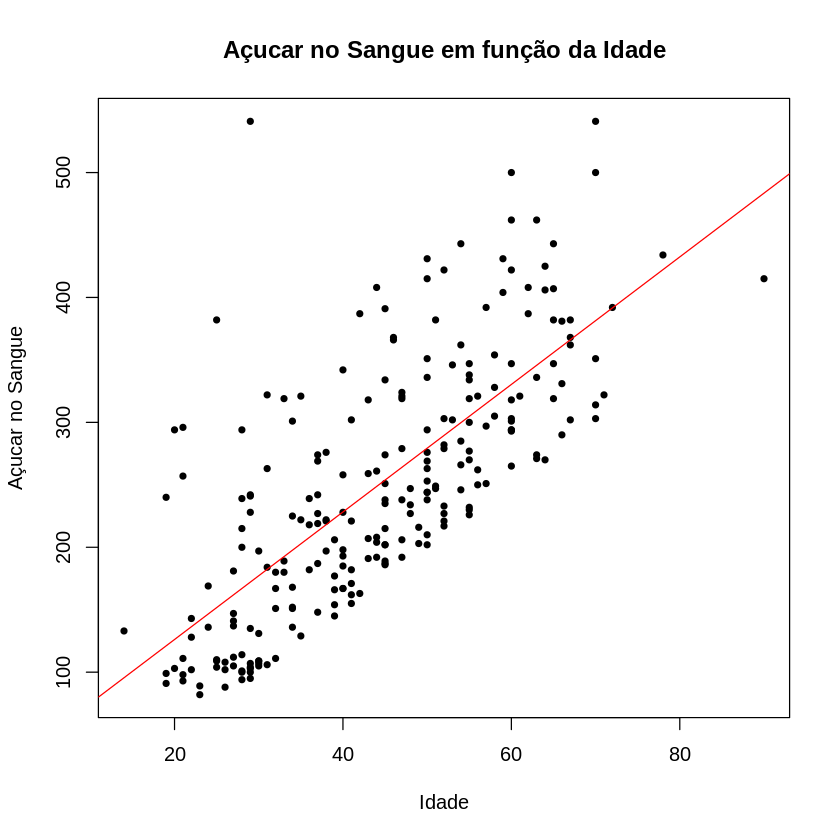

In [ ]:
modeloL=lm(Blood.sugar~Age, data=f);confint(modeloL)


summary(modeloL)
plot(f$Age,f$Blood.sugar, pch=20, xlab= "Idade",
ylab = "Açucar no Sangue", main = "Açucar no Sangue em função da Idade")
abline(modeloL,col="Red")

In [ ]:
modeloL=lm(Blood.sugar~Age, data=f);confint(modeloL)

,2.5 %,97.5 %
(Intercept),-4.964593,53.116362
Age,4.478791,5.731249



	Shapiro-Wilk normality test

data:  residuals(modeloL)
W = 0.878, p-value = 5.926e-13


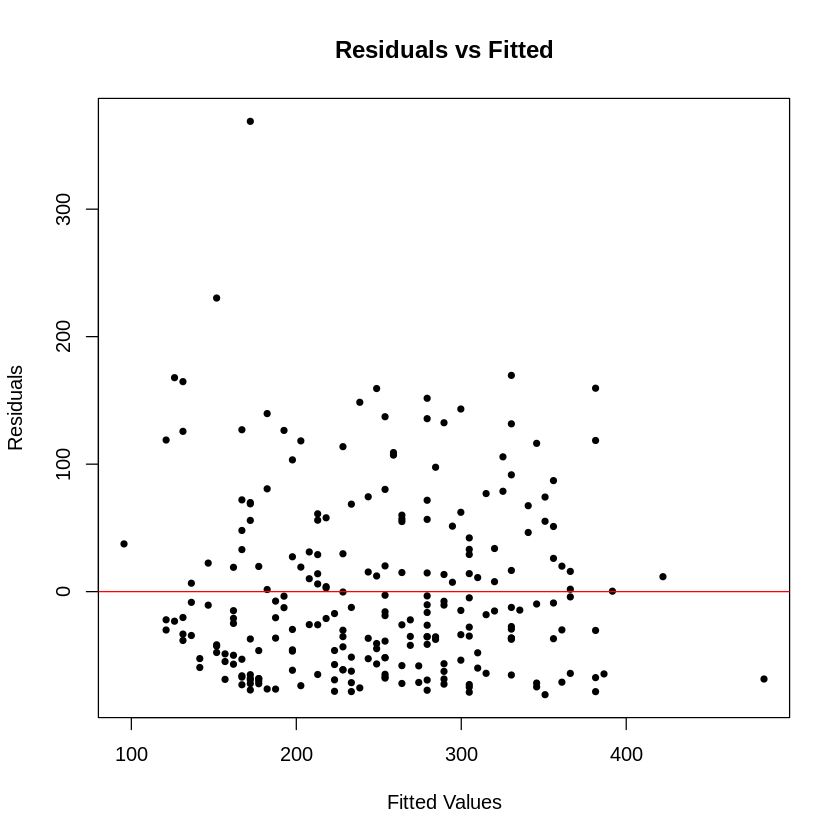

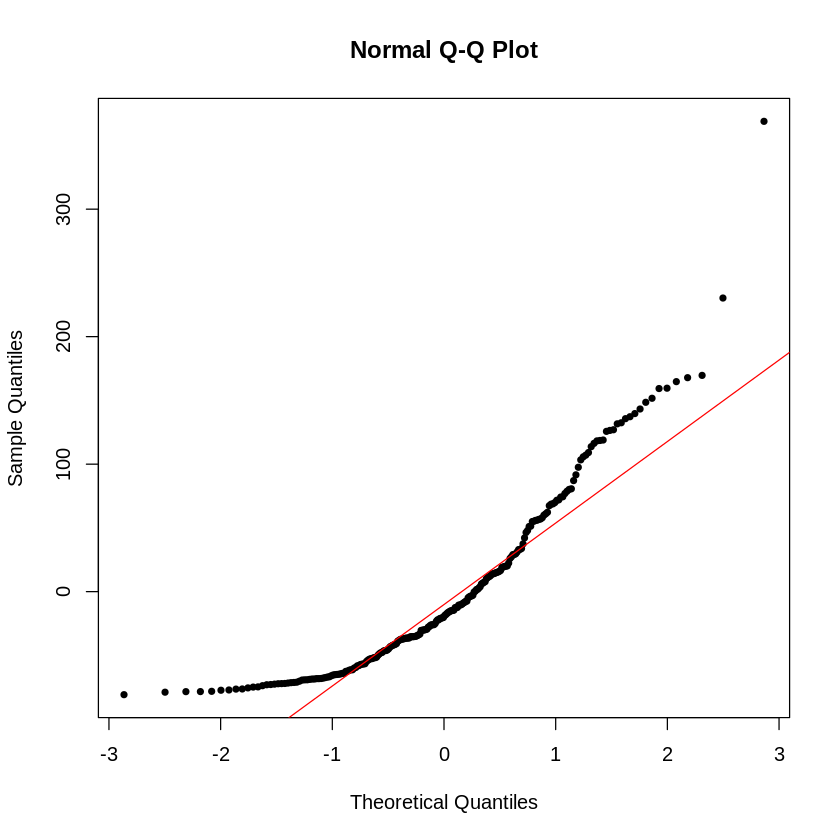

In [ ]:
plot(fitted(modeloL), resid(modeloL), pch=20, xlab= "Fitted Values",
ylab = "Residuals", main = "Residuals vs Fitted")
abline(0,0, col = "red")

#H0: erros seguem a normalidade vs H1: erros não seguem a normalidade
shapiro.test(residuals(modeloL))
#valor p < 0.05, rejeita-se H0

qqnorm(resid(modeloL), pch=20)
qqline(resid(modeloL),col = "red")


In [ ]:
modelo=lm(Heart.rate~Age + Systolic.blood.pressure + Diastolic.blood.pressure +
             Blood.sugar , data=f);
confint(modelo)
summary(modelo)

,2.5 %,97.5 %
(Intercept),58.1701522,80.69535349
Age,-0.2669900,0.08402899
Systolic.blood.pressure,-0.2273867,-0.06822442
Diastolic.blood.pressure,0.2094926,0.52200922
Blood.sugar,-0.0115923,0.03785626



Call:
lm(formula = Heart.rate ~ Age + Systolic.blood.pressure + Diastolic.blood.pressure + 
    Blood.sugar, data = f)

Residuals:
    Min      1Q  Median      3Q     Max 
-27.112 -10.591  -1.450   8.706  38.941 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)              69.43275    5.71674  12.146  < 2e-16 ***
Age                      -0.09148    0.08909  -1.027 0.305534    
Systolic.blood.pressure  -0.14781    0.04039  -3.659 0.000313 ***
Diastolic.blood.pressure  0.36575    0.07931   4.611 6.57e-06 ***
Blood.sugar               0.01313    0.01255   1.046 0.296452    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 13.51 on 235 degrees of freedom
Multiple R-squared:  0.09419,	Adjusted R-squared:  0.07878 
F-statistic: 6.109 on 4 and 235 DF,  p-value: 0.000108


In [ ]:
f$Result_num = ifelse(f$Result == "positive", 1, 0)
str(f)

'data.frame':	240 obs. of  10 variables:
 $ Age                     : int  21 55 64 55 47 37 60 52 30 50 ...
 $ Gender                  : int  1 1 1 1 1 0 1 1 1 1 ...
 $ Heart.rate              : int  94 64 70 64 76 72 92 76 63 63 ...
 $ Systolic.blood.pressure : int  98 160 120 112 120 107 151 109 110 104 ...
 $ Diastolic.blood.pressure: int  46 77 55 65 70 86 78 85 68 63 ...
 $ Blood.sugar             : num  296 270 270 300 319 274 301 227 107 269 ...
 $ CK.MB                   : num  6.75 1.99 13.87 1.08 2.57 ...
 $ Troponin                : num  1.06 0.003 0.122 0.003 0.003 0.003 0.005 0.491 0.003 0.612 ...
 $ Result                  : chr  "positive" "negative" "positive" "negative" ...
 $ Result_num              : num  1 0 1 0 0 0 0 1 1 1 ...


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:  glm(formula = Result_num ~ Troponin, family = binomial, data = f)

Coefficients:
(Intercept)     Troponin  
     -1.824      144.260  

Degrees of Freedom: 239 Total (i.e. Null);  238 Residual
Null Deviance:	    332.3 
Residual Deviance: 200.2 	AIC: 204.2

Waiting for profiling to be done...

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted proba

,2.5 %,97.5 %
(Intercept),-2.415962,-1.30096
Troponin,88.667898,215.63801



Call:
glm(formula = Result_num ~ Troponin, family = binomial, data = f)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -1.8238     0.2837  -6.428 1.29e-10 ***
Troponin    144.2601    32.5973   4.426 9.62e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 332.29  on 239  degrees of freedom
Residual deviance: 200.23  on 238  degrees of freedom
AIC: 204.23

Number of Fisher Scoring iterations: 12


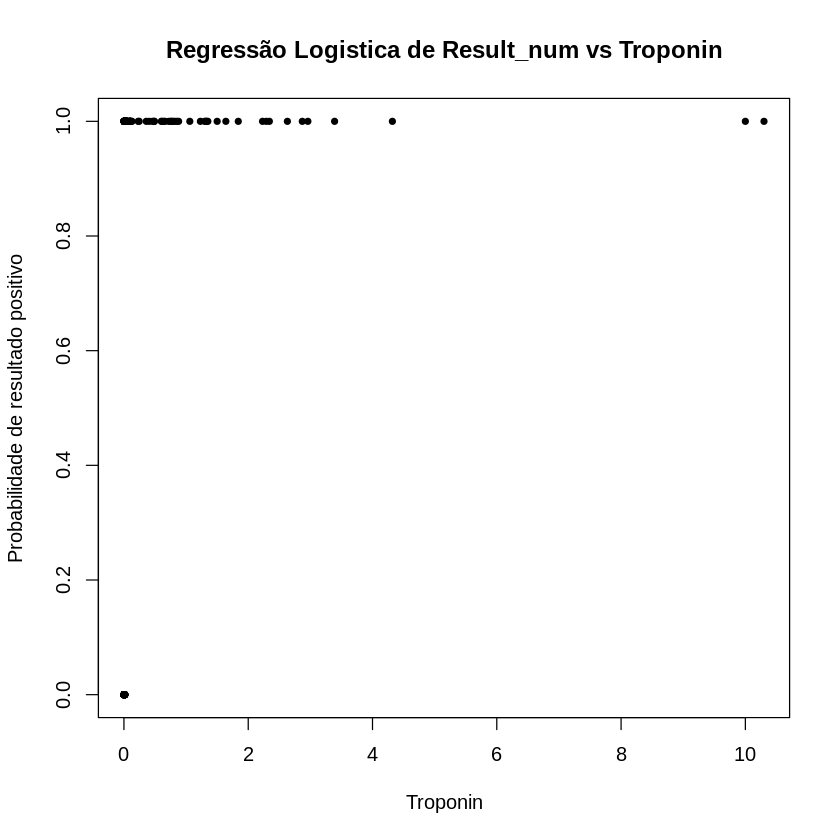

In [ ]:
modeloT = glm(Result_num ~ Troponin,
             family = binomial,
             data = f)
modeloT
confint(modeloT)
summary(modeloT)

plot(f$Troponin, f$Result_num, pch = 20, xlab = "Troponin",
     ylab = "Probabilidade de resultado positivo", main = "Regressão Logistica de Result_num vs Troponin")

#boxplot(f$Troponin, f$Result_num, horizontal = T, xlab = "Níveis de Troponina", ylab="Positivo                                  Negativo",
#main = "Regressão Logistica de Result_num vs Troponin")


In [ ]:
(delta_x=0.051-0.003)
# delta_x = 0.048

(OR = exp(144.2601*delta_x))
# OR = 1017

[1] 0.048

[1] 0.048

[1] 1016.87

[1] 1016.87

In [ ]:
modeloA = glm(Result_num ~ Age + Gender + Heart.rate +
             Systolic.blood.pressure + Diastolic.blood.pressure +
             Blood.sugar + CK.MB + Troponin,
             family = binomial,
             data = f)
confint(modeloA)
summary(modeloA)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Waiting for profiling to be done...

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted proba

,2.5 %,97.5 %
(Intercept),-31.431001297,-8.03555302
Age,-0.133481438,0.08723244
Gender,-4.044303847,-0.03406445
Heart.rate,-0.011880936,0.13957844
Systolic.blood.pressure,-0.022824389,0.09040908
Diastolic.blood.pressure,-0.128431120,0.04886188
Blood.sugar,-0.009392144,0.01976919
CK.MB,1.002590111,2.56155209
Troponin,354.532681719,991.88276548



Call:
glm(formula = Result_num ~ Age + Gender + Heart.rate + Systolic.blood.pressure + 
    Diastolic.blood.pressure + Blood.sugar + CK.MB + Troponin, 
    family = binomial, data = f)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -17.611975   5.823944  -3.024 0.002494 ** 
Age                       -0.018610   0.054627  -0.341 0.733356    
Gender                    -1.841857   0.989646  -1.861 0.062726 .  
Heart.rate                 0.058724   0.037593   1.562 0.118261    
Systolic.blood.pressure    0.027632   0.029403   0.940 0.347339    
Diastolic.blood.pressure  -0.035343   0.043582  -0.811 0.417384    
Blood.sugar                0.004371   0.007211   0.606 0.544367    
CK.MB                      1.609830   0.380935   4.226 2.38e-05 ***
Troponin                 603.671457 155.439149   3.884 0.000103 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to 

In [ ]:
modeloG = glm(Gender ~ CK.MB,
             family = binomial,
             data = f)
confint(modeloG)
summary(modeloG)

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),0.620193071,1.211267403
CK.MB,-0.005446844,0.003774582



Call:
glm(formula = Gender ~ CK.MB, family = binomial, data = f)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.909810   0.150514   6.045  1.5e-09 ***
CK.MB       -0.001072   0.002291  -0.468     0.64    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 289.75  on 239  degrees of freedom
Residual deviance: 289.53  on 238  degrees of freedom
AIC: 293.53

Number of Fisher Scoring iterations: 4


In [ ]:
modeloL=lm(Heart.rate ~ Systolic.blood.pressure +
  Diastolic.blood.pressure + CK.MB , data=f);
confint(modeloL)
summary(modeloL)


,2.5 %,97.5 %
(Intercept),58.8777633,79.15335301
Systolic.blood.pressure,-0.2290499,-0.07037405
Diastolic.blood.pressure,0.2104089,0.52295099
CK.MB,-0.0373363,0.02074030



Call:
lm(formula = Heart.rate ~ Systolic.blood.pressure + Diastolic.blood.pressure + 
    CK.MB, data = f)

Residuals:
    Min      1Q  Median      3Q     Max 
-27.306 -10.714  -1.113   9.255  38.048 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)              69.015558   5.145914  13.412  < 2e-16 ***
Systolic.blood.pressure  -0.149712   0.040272  -3.718 0.000251 ***
Diastolic.blood.pressure  0.366680   0.079323   4.623 6.24e-06 ***
CK.MB                    -0.008298   0.014740  -0.563 0.573991    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 13.51 on 236 degrees of freedom
Multiple R-squared:  0.0906,	Adjusted R-squared:  0.07904 
F-statistic: 7.837 on 3 and 236 DF,  p-value: 5.232e-05


In [ ]:
modeloZ = glm(Result_num ~ Age + Gender +
             Blood.sugar + CK.MB + Troponin,
             family = binomial,
             data = f)
confint(modeloZ)
summary(modeloZ)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Waiting for profiling to be done...

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted proba

,2.5 %,97.5 %
(Intercept),-18.60274005,-6.97888298
Age,-0.11365634,0.08185263
Gender,-3.51900486,0.05306097
Blood.sugar,-0.01097825,0.01536549
CK.MB,1.00455743,2.60967648
Troponin,364.71549730,964.70607496



Call:
glm(formula = Result_num ~ Age + Gender + Blood.sugar + CK.MB + 
    Troponin, family = binomial, data = f)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -11.580206   2.893228  -4.003 6.27e-05 ***
Age          -0.016585   0.049048  -0.338   0.7353    
Gender       -1.614410   0.889534  -1.815   0.0695 .  
Blood.sugar   0.002157   0.006592   0.327   0.7435    
CK.MB         1.624508   0.396282   4.099 4.14e-05 ***
Troponin    608.314082 148.961211   4.084 4.43e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 332.294  on 239  degrees of freedom
Residual deviance:  42.483  on 234  degrees of freedom
AIC: 54.483

Number of Fisher Scoring iterations: 15
